## 1. IMPORT DES BIBLIOTHÈQUES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

## 2. DATASET

In [2]:
data = fetch_california_housing()

# Une seule variable explicative (feature 2 par exemple)
X = data.data
y = data.target

## 3. VISUALISATION DES DONNÉES

Nombre d'exemples: 20640
Nombre de features: 8
Shape de X: (20640, 8)
Shape de y: (20640,)

Statistiques de X:
Moyenne: [ 3.87067100e+00  2.86394864e+01  5.42899974e+00  1.09667515e+00
  1.42547674e+03  3.07065516e+00  3.56318614e+01 -1.19569704e+02]
Écart-type: [1.89977569e+00 1.25852527e+01 2.47411320e+00 4.73899376e-01
 1.13243469e+03 1.03857980e+01 2.13590065e+00 2.00348319e+00]


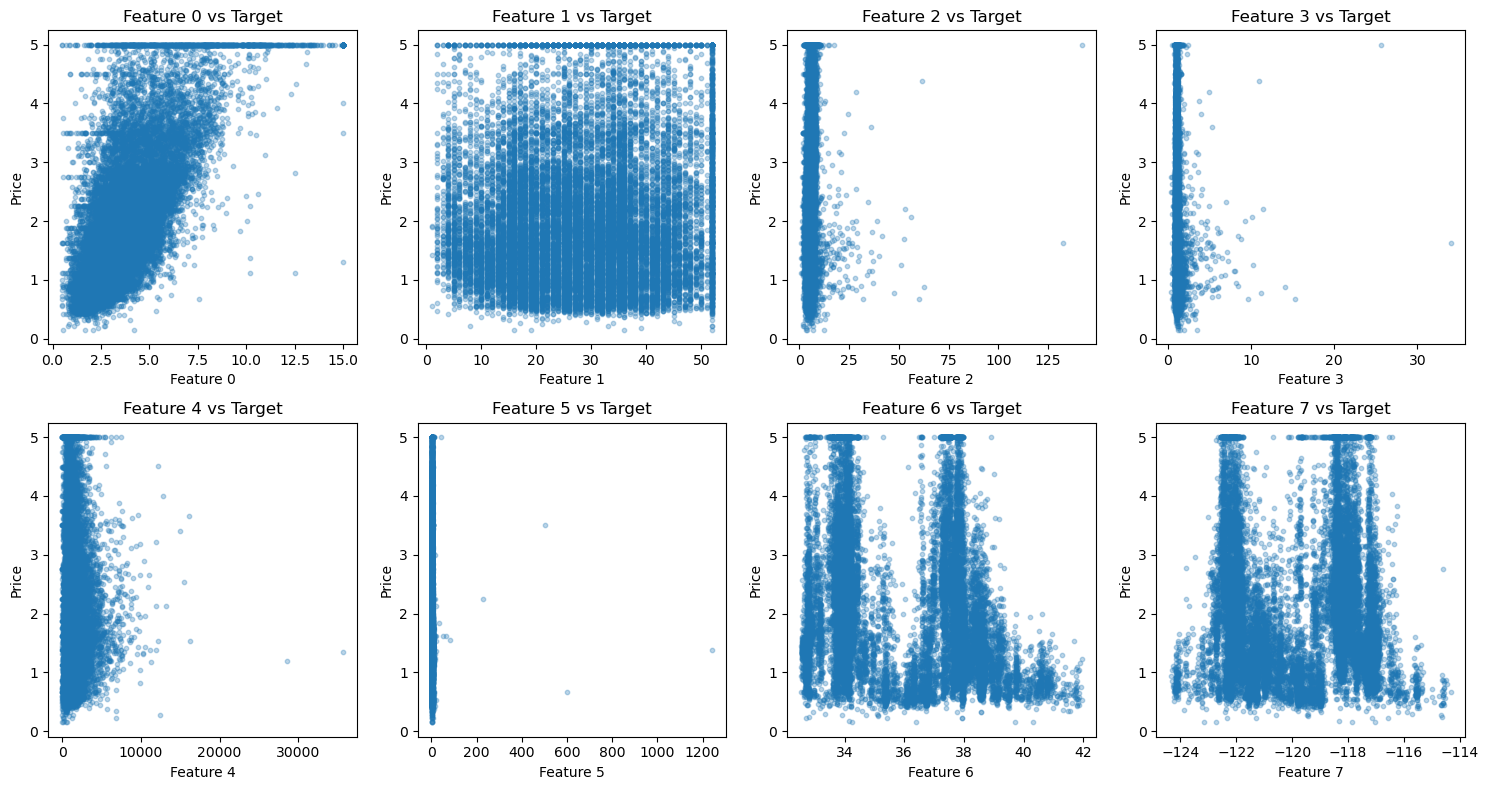

In [3]:
# Affichage des informations du dataset
print(f"Nombre d'exemples: {X.shape[0]}")
print(f"Nombre de features: {X.shape[1]}")
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Affichage statistiques
print("\nStatistiques de X:")
print(f"Moyenne: {X.mean(axis=0)}")
print(f"Écart-type: {X.std(axis=0)}")

# Visualisation d'une feature vs la cible
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i in range(8):
    axes[i].scatter(X[:, i], y, alpha=0.3, s=10)
    axes[i].set_xlabel(f'Feature {i}')
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Feature {i} vs Target')
plt.tight_layout()
plt.show()


## 4. Preprocessing

In [4]:
# Normalisation MinMax ou StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
print("Données normalisées:")
print(f"Moyenne: {X_normalized.mean(axis=0)[:3]}...") 
print(f"Écart-type: {X_normalized.std(axis=0)[:3]}...")


Données normalisées:
Moyenne: [6.60969987e-17 5.50808322e-18 6.60969987e-17]...
Écart-type: [1. 1. 1.]...


In [5]:
# Utiliser les données normalisées pour l'apprentissage
X = X_normalized
print(f"X après normalisation: {X.shape}")


X après normalisation: (20640, 8)


## 5. INITIALISATION DES PARAMÈTRES

In [6]:
# Initialiser les thetas (avec biais inclus)
thetas = np.zeros(X.shape[1])

learning_rate = 0.01
epochs = 100
m = X.shape[0]  # nombre d'exemples


## 6. FONCTIONS DE LA DESCENTE DU GRADIENT

In [7]:
def prediction(X, thetas):
    """Calcule les prédictions: y_pred = X @ thetas"""
    return X @ thetas


def cost_function(X, y, thetas):
    """Calcule l'erreur quadratique moyenne (MSE)"""
    m = X.shape[0]
    predictions = prediction(X, thetas)
    mse = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return mse


def gradients(X, y, thetas):
    """Calcule les gradients de la fonction de coût"""
    m = X.shape[0]
    predictions = prediction(X, thetas)
    errors = predictions - y
    d_thetas = (1 / m) * X.T @ errors
    return d_thetas


In [8]:
# Descente du gradient
cost_history = []
cost = cost_function(X, y, thetas)
cost_history.append(cost)

for epoch in range(epochs):
    # Calculer les gradients
    grad = gradients(X, y, thetas)
    
    # Mettre à jour les thetas
    thetas = thetas - learning_rate * grad
    
    # Calculer et enregistrer le coût
    cost = cost_function(X, y, thetas)
    cost_history.append(cost)
    
    # Afficher le progrès tous les 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Cost: {cost:.6f}")

print(f"\nEntraînement terminé! Coût final: {cost:.6f}")


Epoch 10/100, Cost: 2.740942
Epoch 20/100, Cost: 2.688996
Epoch 30/100, Cost: 2.646887
Epoch 40/100, Cost: 2.612639
Epoch 50/100, Cost: 2.584697
Epoch 60/100, Cost: 2.561829
Epoch 70/100, Cost: 2.543054
Epoch 80/100, Cost: 2.527589
Epoch 90/100, Cost: 2.514807
Epoch 100/100, Cost: 2.504206

Entraînement terminé! Coût final: 2.504206


In [9]:
# Affichage des paramètres finaux
print("\nParamètres appris (thetas):")
for i, theta in enumerate(thetas):
    print(f"theta[{i}] = {theta:.6f}")

# Évaluation sur les données d'entraînement
y_pred = prediction(X, thetas)
mse_final = cost_function(X, y, thetas)
rmse_final = np.sqrt(2 * mse_final)  # RMSE
print(f"\nErreur quadratique moyenne (MSE): {mse_final:.6f}")
print(f"Racine de l'erreur quadratique (RMSE): {rmse_final:.6f}")



Paramètres appris (thetas):
theta[0] = 0.492246
theta[1] = 0.102203
theta[2] = 0.068820
theta[3] = -0.043365
theta[4] = -0.008032
theta[5] = -0.021216
theta[6] = -0.114329
theta[7] = -0.067144

Erreur quadratique moyenne (MSE): 2.504206
Racine de l'erreur quadratique (RMSE): 2.237948


## 7. VISUALISATION du cout

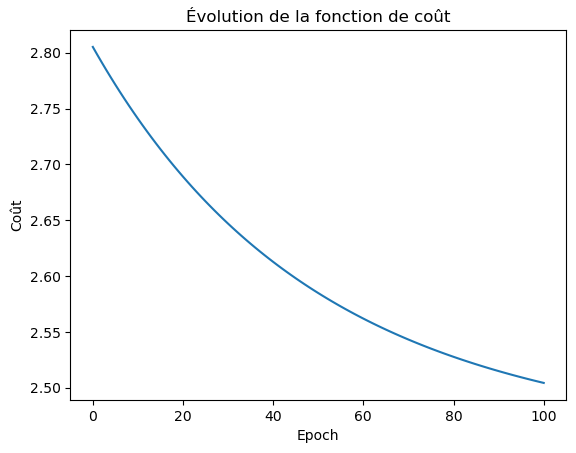

In [10]:
# la courbe de convergence
plt.plot(cost_history)
plt.title("Évolution de la fonction de coût")
plt.xlabel("Epoch")
plt.ylabel("Coût")
plt.show()